Sensitivity analysis for the long-term warming modifier using the fixed linear seasonal-strength formulation `S = A / A_max` and `SEASONAL_ALPHA = 0.10`. Surface and seafloor regions are processed independently.

In [1]:
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
BASE_DIR = Path("C:/Users/shw1/Documents/GitHub/MHW_risk_framework")
MHW_METRICS_DIR = BASE_DIR / "data" / "MHW_metrics"

REGIONS = {
    "EAC_jet": {"label": "EAC jet"},
    "Separation_zone": {"label": "Separation zone"},
    "Southern_extension": {"label": "Southern extension"},
}
DOMAINS = ["surface", "seafloor"]

SEASONAL_ALPHA = 0.10
BETA_VALUES = np.round(np.arange(0.0, 1.0001, 0.05), 2)
COMPONENT_WEIGHTS = {"frequency": 1.0, "duration": 1.0, "intensity": 1.0}

BETA_REF = 0.0
TOP_FRAC = 0.20
SPEARMAN_TH = 0.90
OVERLAP_TH = 0.90
JACCARD_TH = 0.82

In [3]:
def standardize_region(da: xr.DataArray, mask: xr.DataArray | None = None) -> xr.DataArray:
    if mask is not None:
        da = da.where(mask)
    mean = da.mean(skipna=True)
    std = da.std(skipna=True)
    return xr.where(std > 0, (da - mean) / std, np.nan)


def drop_nuisance_coords(da: xr.DataArray) -> xr.DataArray:
    names = [c for c in ["ocean_time", "quantile", "band", "crs"] if c in da.coords and c not in da.dims]
    return da.reset_coords(names, drop=True) if names else da


def ensure_day_of_year_name(da: xr.DataArray) -> xr.DataArray:
    for candidate in ["day_of_year", "doy", "DOY", "DAY_OF_YEAR", "ocean_time", "time", "doy365"]:
        if candidate in da.dims:
            if candidate != "day_of_year":
                da = da.rename({candidate: "day_of_year"})
            return da.assign_coords(day_of_year=np.arange(1, da.sizes["day_of_year"] + 1))
    raise ValueError(f"No day-of-year dimension found in {da.dims}")


def align_doy_to_time(doy_da: xr.DataArray, time: xr.DataArray) -> xr.DataArray:
    doy_da = ensure_day_of_year_name(drop_nuisance_coords(doy_da))
    doy = time.dt.dayofyear
    # Match the final SHI convention: remove 29 February from leap-year indexing.
    doy = xr.where(time.dt.is_leap_year & (doy > 59), doy - 1, doy)
    index = xr.DataArray((doy - 1).astype("int32").data, dims=["time"], coords={"time": time})
    return doy_da.isel(day_of_year=index).reset_coords("day_of_year", drop=True).assign_coords(time=time)


def time_to_years(time_da: xr.DataArray) -> xr.DataArray:
    values = ((time_da.values - time_da.values[0]) / np.timedelta64(1, "D")) / 365.25
    return xr.DataArray(values, dims=["time"], coords={"time": time_da})


def _safe_slope_1d(y: np.ndarray, x: np.ndarray) -> float:
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    valid = np.isfinite(y) & np.isfinite(x)
    return float(np.polyfit(x[valid], y[valid], 1)[0]) if valid.sum() >= 10 else np.nan


def calculate_trend_map(temp: xr.DataArray, *, time_dim: str = "time") -> xr.DataArray:
    if time_dim != "time":
        temp = temp.rename({time_dim: "time"})
    x = time_to_years(temp["time"])
    return xr.apply_ufunc(
        _safe_slope_1d, temp, x,
        input_core_dims=[["time"], ["time"]], output_core_dims=[[]],
        vectorize=True, dask="parallelized", output_dtypes=[float],
    )

In [4]:
def calculate_seasonality_term(
    clim50: xr.DataArray, *, alpha: float, mask: xr.DataArray | None = None,
) -> xr.Dataset:
    clim50 = drop_nuisance_coords(ensure_day_of_year_name(clim50))
    if clim50.chunks is not None:
        clim50 = clim50.chunk({"day_of_year": -1})

    q95 = drop_nuisance_coords(clim50.quantile(0.95, "day_of_year", skipna=True))
    q05 = drop_nuisance_coords(clim50.quantile(0.05, "day_of_year", skipna=True))
    amplitude = q95 - q05
    if mask is not None:
        amplitude = amplitude.where(mask)
    maximum = amplitude.max(skipna=True)
    amplitude_max = float(maximum.compute()) if hasattr(maximum, "compute") else float(maximum)
    if not np.isfinite(amplitude_max) or amplitude_max <= 0:
        raise ValueError("Seasonal amplitude maximum must be finite and positive.")

    # Linear scaling retains proportional differences without saturation.
    strength = amplitude / amplitude_max
    strength = strength.clip(0, 1).where(np.isfinite(amplitude))

    tmin = clim50.min("day_of_year", skipna=True)
    tmax = clim50.max("day_of_year", skipna=True)
    denominator = tmax - tmin
    position = xr.where(
        np.isfinite(denominator) & (denominator > 0),
        2 * ((clim50 - tmin) / denominator) - 1, 0.0,
    ).clip(-1, 1)
    weight = 1 + alpha * strength * position
    weight = weight / weight.mean("day_of_year", skipna=True)
    weight = weight.where(np.isfinite(amplitude))

    return xr.Dataset({
        "seasonality_amplitude_A": amplitude.astype("float32"),
        "seasonality_strength_S": strength.astype("float32"),
        "seasonal_position_h": position.astype("float32"),
        "seasonal_weight_doy": weight.astype("float32"),
    }, attrs={
        "A_max": amplitude_max,
        "alpha": float(alpha),
        "strength_formula": "S = A / A_max within region and domain",
        "weight_formula": "w = 1 + alpha * S * h, normalised to annual mean one",
    })


In [5]:
def _seasonally_adjusted_event_metrics_1d(event, positive_anomaly, seasonal_weight, years):
    event = np.asarray(event, dtype=bool)
    anomaly = np.asarray(positive_anomaly, dtype=float)
    weight = np.asarray(seasonal_weight, dtype=float)
    years = np.asarray(years)
    n_years = np.unique(years).size
    durations, intensities = [], []

    i = 0
    while i < event.size:
        if not event[i]:
            i += 1
            continue
        j = i
        while j < event.size and event[j]:
            j += 1
        event_weight = weight[i:j]
        event_anomaly = anomaly[i:j]
        valid_duration = np.isfinite(event_weight)
        durations.append(float(event_weight[valid_duration].sum()) if valid_duration.any() else np.nan)
        positive = np.isfinite(event_anomaly) & np.isfinite(event_weight) & (event_anomaly > 0)
        intensities.append(float(np.mean(event_anomaly[positive] * event_weight[positive])) if positive.any() else 0.0)
        i = j

    if not durations:
        return np.array([0.0, 0.0, 0.0], dtype=float)
    return np.array([len(durations) / n_years, np.nanmean(durations), np.nanmean(intensities)], dtype=float)


def calculate_weighted_mhw_metrics(event_mask, positive_anomaly, seasonal_weight_time):
    event_mask, positive_anomaly, seasonal_weight_time = xr.align(
        event_mask.fillna(False).astype(bool), positive_anomaly, seasonal_weight_time, join="exact",
    )
    years = xr.DataArray(event_mask.time.dt.year)
    metrics = xr.apply_ufunc(
        _seasonally_adjusted_event_metrics_1d,
        event_mask, positive_anomaly, seasonal_weight_time, years,
        input_core_dims=[["time"], ["time"], ["time"], ["time"]],
        output_core_dims=[["metric"]], vectorize=True, dask="parallelized",
        output_dtypes=[float], dask_gufunc_kwargs={"output_sizes": {"metric": 3}},
    ).assign_coords(metric=["F_over_T", "D_bar_weighted_days", "I_bar_weighted_degC"])
    return metrics.to_dataset(dim="metric").astype("float32")


def calculate_warming_modifier(temp: xr.DataArray, mask: xr.DataArray, *, beta: float) -> xr.Dataset:
    trend = calculate_trend_map(temp).where(mask)
    if np.isclose(beta, 0.0):
        # Neutral modifier isolates alpha and avoids an unnecessary division by mean trend.
        modifier = xr.ones_like(trend).where(mask)
    else:
        regional_mean = float(trend.mean(skipna=True).compute().item())
        if not np.isfinite(regional_mean) or np.isclose(regional_mean, 0.0):
            raise ValueError("Regional mean trend must be finite and different from zero.")
        modifier = (1 + beta * (trend / regional_mean)).where(mask)
    return xr.Dataset({
        "temperature_trend_degC_per_year": trend.astype("float32"),
        "warming_modifier": modifier.astype("float32"),
    })


def calculate_shi(F_over_T, D_bar_weighted, I_bar_weighted, warming_modifier, mask):
    F, D, I, W, mask = xr.align(F_over_T, D_bar_weighted, I_bar_weighted, warming_modifier, mask, join="exact")
    Fz, Dz, Iz = (standardize_region(x, mask) for x in (F, D, I))
    exposure = (
        COMPONENT_WEIGHTS["frequency"] * Fz
        + COMPONENT_WEIGHTS["duration"] * Dz
        + COMPONENT_WEIGHTS["intensity"] * Iz
    )
    risk_raw = (exposure * W).where(mask)
    shi = standardize_region(risk_raw, mask)
    return xr.Dataset({
        "SHI": shi.astype("float32"), "exposure": exposure.astype("float32"),
        "risk_raw": risk_raw.astype("float32"), "F_z": Fz.astype("float32"),
        "D_z": Dz.astype("float32"), "I_z": Iz.astype("float32"),
    })


In [6]:
def calculate_fixed_exposure(ds: xr.Dataset, alpha: float = SEASONAL_ALPHA):
    mask = ds["mask"] == 1
    temp = ds["temperature"]
    seasonality = calculate_seasonality_term(ds["clim50"], alpha=alpha, mask=mask)
    weight_time = align_doy_to_time(seasonality["seasonal_weight_doy"], temp.time)
    metrics = calculate_weighted_mhw_metrics(
        ds["event_mask"] == 1,
        ds["positive_intensity_anomaly"],
        weight_time,
    ).where(mask)

    Fz = standardize_region(metrics["F_over_T"], mask)
    Dz = standardize_region(metrics["D_bar_weighted_days"], mask)
    Iz = standardize_region(metrics["I_bar_weighted_degC"], mask)
    exposure = (
        COMPONENT_WEIGHTS["frequency"] * Fz
        + COMPONENT_WEIGHTS["duration"] * Dz
        + COMPONENT_WEIGHTS["intensity"] * Iz
    ).where(mask)
    return seasonality, metrics, exposure, mask


def calculate_shi_from_exposure(exposure, warming_modifier, mask):
    exposure, warming_modifier, mask = xr.align(exposure, warming_modifier, mask, join="exact")
    risk_raw = (exposure * warming_modifier).where(mask)
    return standardize_region(risk_raw, mask).astype("float32")


def run_beta_for_dataset(ds, exposure, mask, trend, mean_trend, beta):
    modifier = (1 + beta * (trend / mean_trend)).where(mask)
    shi = calculate_shi_from_exposure(exposure, modifier, mask)
    return xr.Dataset({
        "SHI": shi,
        "exposure": exposure.astype("float32"),
        "temperature_trend_degC_per_year": trend.astype("float32"),
        "warming_modifier": modifier.astype("float32"),
        "mask": mask.astype("int8"),
    }, attrs={
        "seasonal_alpha": SEASONAL_ALPHA,
        "seasonal_strength_formula": "S = A / A_max within region and domain",
        "warming_beta": float(beta),
    })


In [7]:
def _paired_values(a, b):
    a, b = xr.align(a, b, join="exact")
    av, bv = a.values.ravel(), b.values.ravel()
    valid = np.isfinite(av) & np.isfinite(bv)
    return av[valid], bv[valid]


def top_fraction_mask(da, fraction=TOP_FRAC):
    values = da.values[np.isfinite(da.values)]
    if values.size == 0:
        return xr.zeros_like(da, dtype=bool)
    return (da >= np.quantile(values, 1 - fraction)) & np.isfinite(da)


def compare_shi(candidate, reference):
    av, bv = _paired_values(candidate, reference)
    rho = float(spearmanr(av, bv).correlation) if av.size >= 10 else np.nan
    top_candidate, top_reference = xr.align(
        top_fraction_mask(candidate), top_fraction_mask(reference), join="exact"
    )
    candidate_set = top_candidate.values.ravel().astype(bool)
    reference_set = top_reference.values.ravel().astype(bool)
    intersection = np.logical_and(candidate_set, reference_set).sum()
    union = np.logical_or(candidate_set, reference_set).sum()
    return {
        "spearman_vs0": rho,
        "top_fraction_overlap_vs0": float(intersection / reference_set.sum()) if reference_set.sum() else np.nan,
        "jaccard_vs0": float(intersection / union) if union else np.nan,
    }

In [8]:
def run_warming_sensitivity(metrics_dir=MHW_METRICS_DIR):
    rows, maps = [], {}

    for domain in DOMAINS:
        for region_name, config in REGIONS.items():
            print(f"Running {domain} / {config['label']}")
            with xr.open_dataset(metrics_dir / f"{domain}_{region_name}_mhw_metrics.nc") as source_ds:
                ds = source_ds.load()

            _, _, exposure, mask = calculate_fixed_exposure(ds, alpha=SEASONAL_ALPHA)
            trend = calculate_trend_map(ds["temperature"]).where(mask)
            mean_trend = float(trend.mean(skipna=True).compute().item())
            if not np.isfinite(mean_trend) or np.isclose(mean_trend, 0.0):
                raise ValueError(f"{domain}/{region_name}: regional mean trend must be finite and non-zero")

            key = (domain, region_name)
            maps[key] = {}
            for beta in BETA_VALUES:
                beta = float(beta)
                result = run_beta_for_dataset(ds, exposure, mask, trend, mean_trend, beta)
                maps[key][beta] = result["SHI"]

            reference = maps[key][BETA_REF]
            for beta, shi in maps[key].items():
                rows.append({
                    "domain": domain,
                    "region": region_name,
                    "region_label": config["label"],
                    "beta": beta,
                    **compare_shi(shi, reference),
                })

    results = pd.DataFrame(rows).sort_values(["domain", "region", "beta"]).reset_index(drop=True)
    results["passes_all"] = (
        (results["spearman_vs0"] >= SPEARMAN_TH)
        & (results["top_fraction_overlap_vs0"] >= OVERLAP_TH)
        & (results["jaccard_vs0"] >= JACCARD_TH)
    )
    return results, maps

In [9]:
warming_df, warming_maps = run_warming_sensitivity()

Running surface / EAC jet
Running surface / Separation zone
Running surface / Southern extension
Running seafloor / EAC jet
Running seafloor / Separation zone
Running seafloor / Southern extension


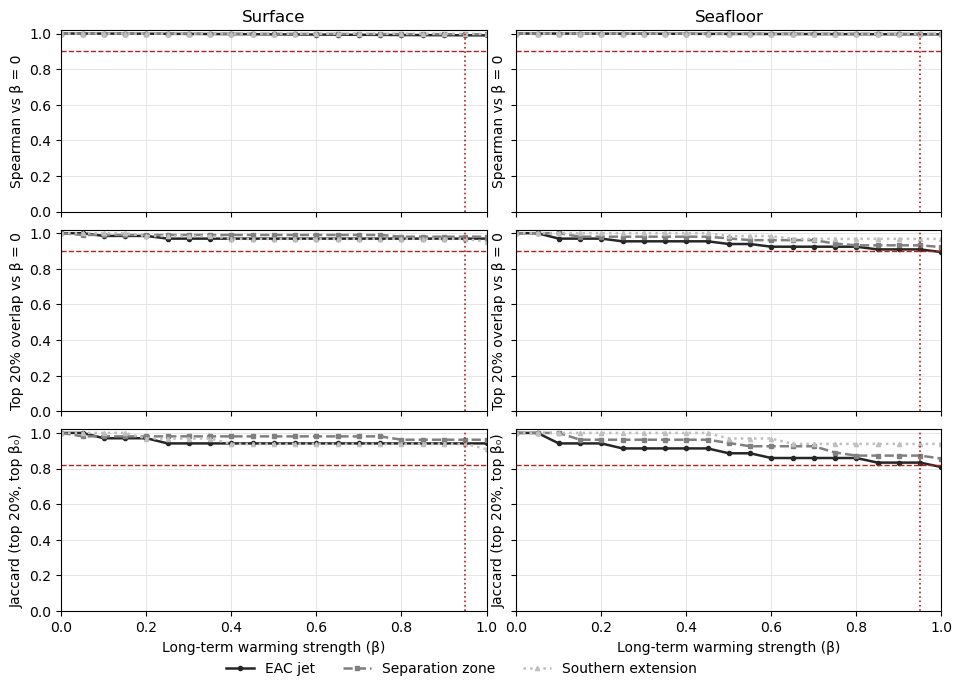

In [10]:
def select_recommended_beta(results):
    combinations = results[["domain", "region"]].drop_duplicates().shape[0]
    pass_counts = results.groupby("beta")["passes_all"].sum()
    valid = pass_counts[pass_counts == combinations].index.to_numpy(dtype=float)
    return float(valid.max()) if valid.size else np.nan


recommended_beta = select_recommended_beta(warming_df)

metrics = [
    ("spearman_vs0", "Spearman vs β = 0", SPEARMAN_TH),
    ("top_fraction_overlap_vs0", f"Top {TOP_FRAC:.0%} overlap vs β = 0", OVERLAP_TH),
    ("jaccard_vs0", f"Jaccard (top {TOP_FRAC:.0%}, top β₀)", JACCARD_TH),
]

styles = {
    "EAC_jet": {"color": "0.15", "linestyle": "-", "marker": "o"},
    "Separation_zone": {"color": "0.50", "linestyle": "--", "marker": "s"},
    "Southern_extension": {"color": "0.75", "linestyle": ":", "marker": "^"},
}

fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey="row")
for col, domain in enumerate(DOMAINS):
    for row, (metric, ylabel, threshold) in enumerate(metrics):
        ax = axes[row, col]
        for region_name, config in REGIONS.items():
            subset = warming_df[
                (warming_df["domain"] == domain) & (warming_df["region"] == region_name)
            ].sort_values("beta")
            style = styles[region_name]
            ax.plot(
                subset["beta"], subset[metric],
                color=style["color"], linestyle=style["linestyle"],
                marker=style["marker"], markersize=3, linewidth=1.8,
                label=config["label"],
            )
        ax.axhline(threshold, color="firebrick", linestyle="--", linewidth=1)
        if np.isfinite(recommended_beta):
            ax.axvline(recommended_beta, color="firebrick", linestyle=":", linewidth=1.2)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        ax.set_ylabel(ylabel)
        ax.grid(color="0.90", linewidth=0.7)
        if row == 0:
            ax.set_title(domain.capitalize())
        if row == 2:
            ax.set_xlabel("Long-term warming strength (β)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=3, frameon=False)
fig.subplots_adjust(left=0.10, right=0.98, top=0.95, bottom=0.12, wspace=0.07, hspace=0.10)
plt.show()